In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

In [4]:
data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')

In [5]:
data

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [7]:
data.isnull().sum()

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

In [8]:
data = data.drop_duplicates()

### **EDA**

<Axes: xlabel='class', ylabel='count'>

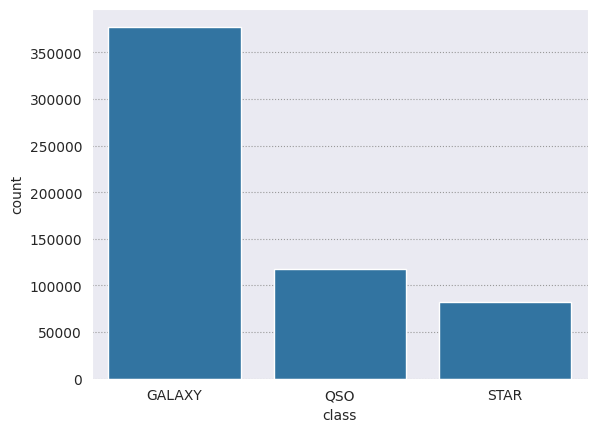

In [9]:
sns.countplot(data = data, x = 'class')

Our goal is a predicting a class of space object. We have three classes with significant prevelance of GALAXY class. 

<Axes: xlabel='spectral_type', ylabel='count'>

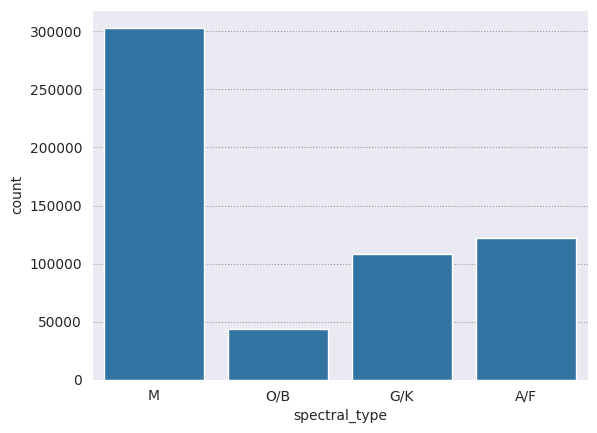

In [20]:
sns.countplot(data = data, x = 'spectral_type')

<Axes: xlabel='galaxy_population', ylabel='count'>

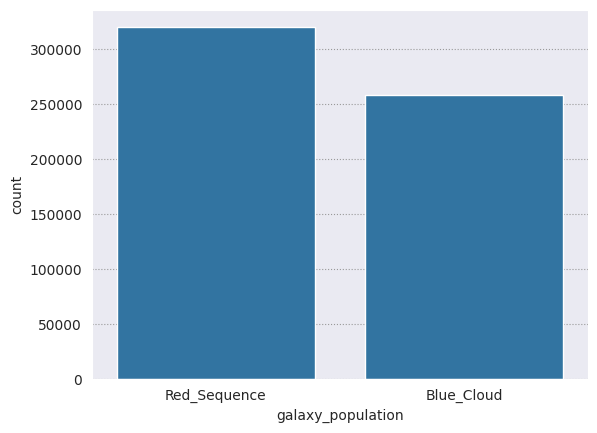

In [21]:
sns.countplot(data = data, x = 'galaxy_population')

In [60]:
cont_col = list(data.columns[1:9])
cat_col = ['spectral_type', 'galaxy_population']
all_cat_col = ['spectral_type', 'galaxy_population', 'class']
target = 'class'

In [23]:
def plot(data, x, target):
    df1 = data.groupby(x)[target].value_counts(normalize=True)
    df1 = df1.mul(100)
    df1 = df1.rename('percent').reset_index()
    
    g = sns.catplot(x=x,y='percent',hue=target,kind='bar',data=df1, height = 7, aspect = 3)
    g.ax.set_ylim(0,100)
        
    for p in g.ax.patches:
        txt = str(round(p.get_height(), 2)) + '%'
        txt_x = p.get_x() 
        txt_y = p.get_height()
        g.ax.text(txt_x,txt_y,txt)

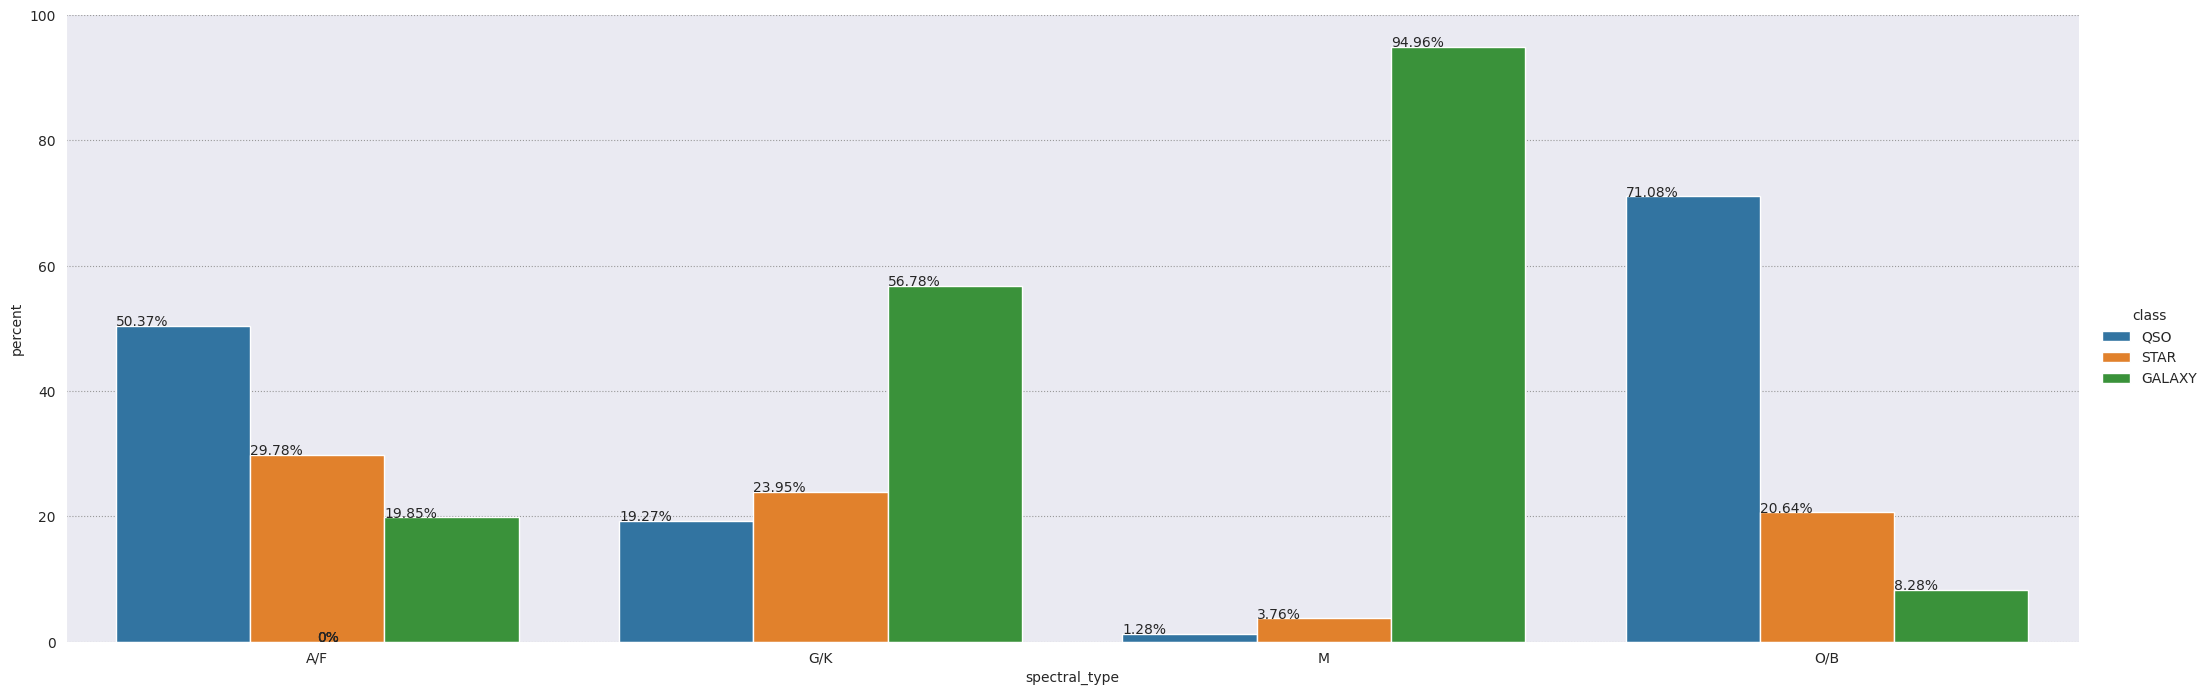

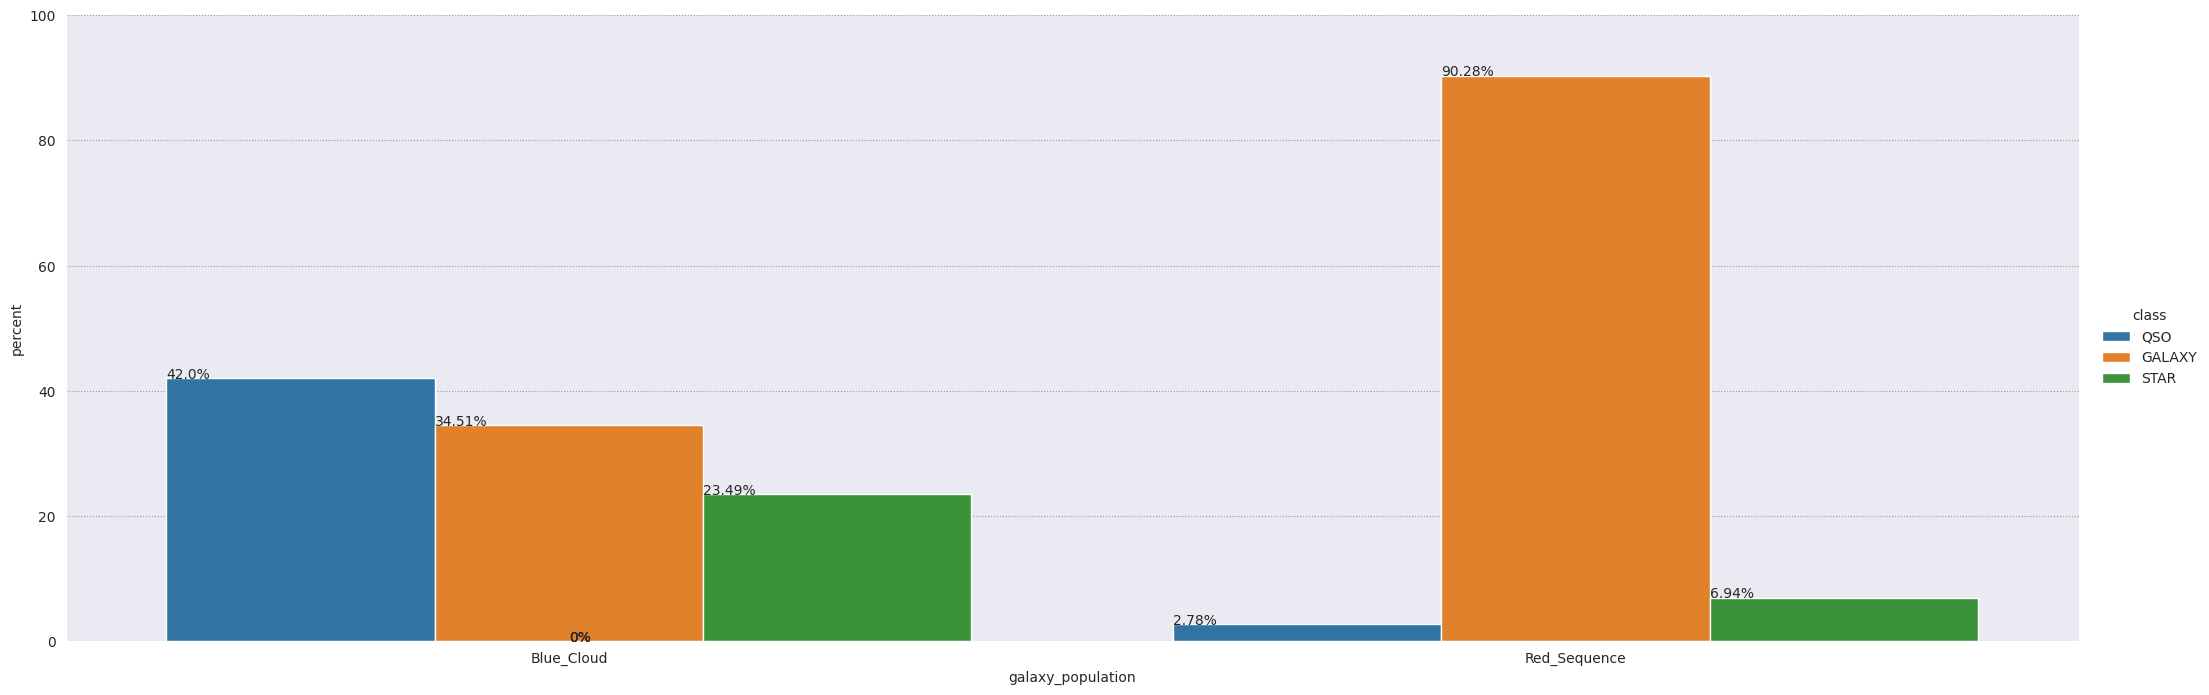

In [24]:
for i in range(len(cat_col)):
    plot(data, cat_col[i], target)

The countplots show us that with a some specific value in spectral_type or galaxy_population we can predict target class

In [13]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
data[['labeled_spectral_type', 'labeled_galaxy_population', 'labeled_class']] = data[all_cat_col].apply(LE.fit_transform)
data[['labeled_spectral_type', 'labeled_galaxy_population', 'labeled_class']]

,labeled_spectral_type,labeled_galaxy_population,labeled_class
0,2,1,0
1,2,1,0
2,3,0,1
3,2,1,0
4,2,1,0
...,...,...,...
577342,2,1,0
577343,2,1,0
577344,2,1,0
577345,1,0,1


In [12]:
lab_cat_col = ['labeled_spectral_type', 'labeled_galaxy_population', 'labeled_class']

<Axes: >

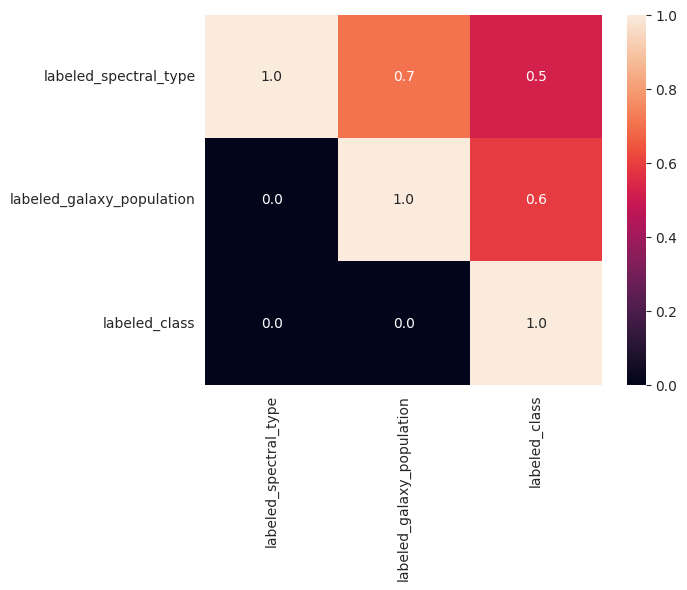

In [27]:

corr_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(i, 3):
        if (i == j):
            corr_matrix[i, j] = 1
            continue
        cross_tab = pd.crosstab(data[lab_cat_col[i]], data[lab_cat_col[j]])
        corr_matrix[i, j] = sp.stats.contingency.association(cross_tab, method='cramer')
corr_matrix = pd.DataFrame(corr_matrix, columns = lab_cat_col, index = lab_cat_col)
sns.heatmap(corr_matrix, annot=True, fmt=".1f")        

<Axes: >

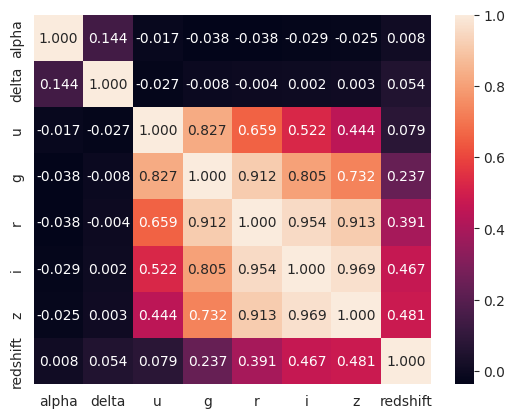

In [28]:

sns.heatmap(data[cont_col].corr(), annot=True, fmt=".3f")        

Let's create the variables what can help to predict our target. We will create them according to the existing data 
https://www-star.fnal.gov/ugriz/tab08.dat

In [14]:
data['u-g'] = data['u'] - data['g']
data['g-r'] = data['g'] - data['r']
data['r-i'] = data['r'] - data['i']
data['i-z'] = data['i'] - data['z']


Let's check their multicollinearity 

In [61]:
VIF             = pd.DataFrame()
VIF['feature']  = data[cont_col].columns
VIF['VIF']      = [variance_inflation_factor(data[cont_col].values, i) for i in range(data[cont_col].shape[1])]
# take a look
VIF

,feature,VIF
0,alpha,4.589543
1,delta,2.372403
2,u,432.007520
3,g,2106.728709
4,r,4867.321332
5,i,4615.373919
6,z,2716.076785
7,redshift,2.212667


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
cont_col  += ['u-g', 'g-r', 'r-i', 'i-z']
VIF             = pd.DataFrame()
VIF['feature']  = data[cont_col].columns
VIF['VIF']      = [variance_inflation_factor(data[cont_col].values, i) for i in range(data[cont_col].shape[1])]
# take a look
VIF

,feature,VIF
0,alpha,4.589543
1,delta,2.372403
2,u,inf
3,g,inf
4,r,inf
5,i,inf
6,z,inf
7,redshift,2.212667
8,u-g,inf
9,g-r,inf


In [17]:
cont_col  = cont_col[:2] + cont_col[7:] + ['r']
VIF             = pd.DataFrame()
VIF['feature']  = data[cont_col].columns
VIF['VIF']      = [variance_inflation_factor(data[cont_col].values, i) for i in range(data[cont_col].shape[1])]
# take a look
VIF

,feature,VIF
0,alpha,4.589543
1,delta,2.372403
2,redshift,2.212667
3,u-g,inf
4,g-r,inf
5,r-i,inf
6,i-z,inf
7,u-g,inf
8,g-r,inf
9,r-i,inf


Without initial variables u, g, i, z we have the acceptable values of VIF for all feauters, except one. But we are going to use decision tree, so one variable with high multicollinearity will not make huge problems but a higher precision   

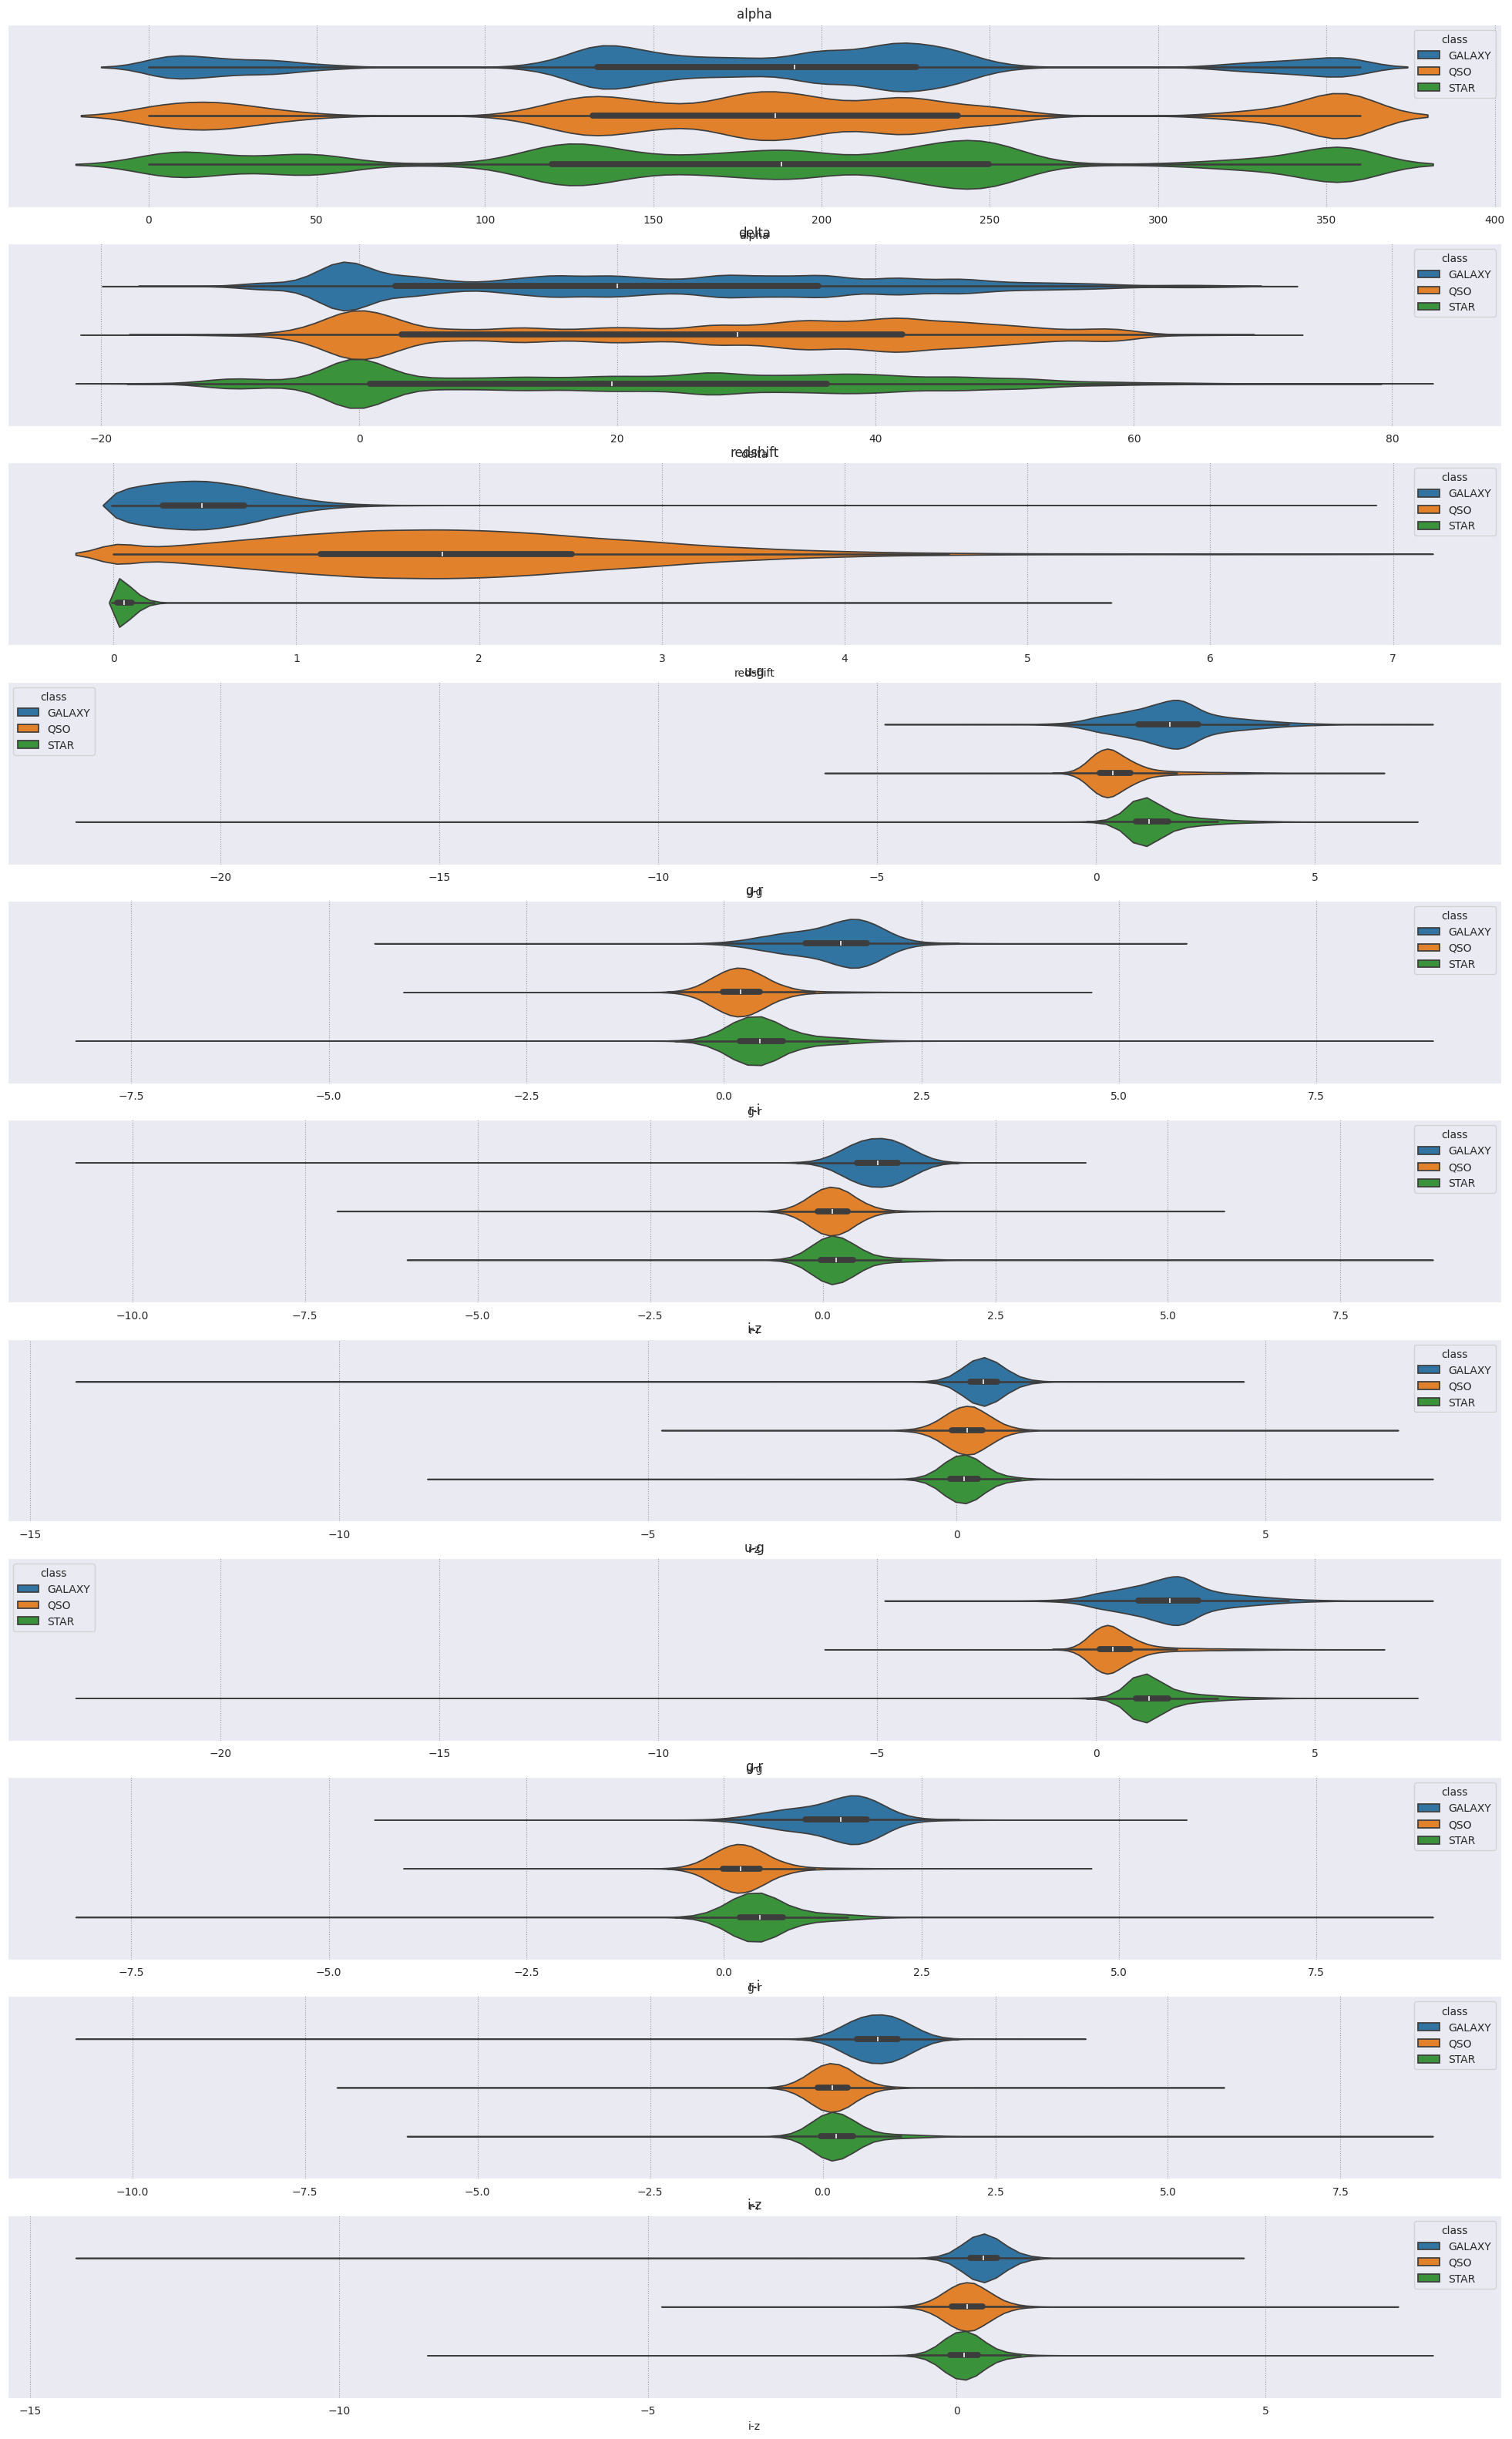

In [20]:
fig, axes = plt.subplots(len(cont_col), figsize = (25, 40))
i = 0
for col in cont_col:

    sns.violinplot(data = data, x = col, hue = target,
                 ax = axes[i]).set_title(col)
    i += 1

We can see, what distribution of new variables according to the target classes are different. It will be helpful in future

### **TRAINING MODEL**

In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
X = data.drop(columns = target)
X.drop(columns = ['id', 'u', 'g', 'i', 'z'], inplace = True)
X.drop(columns = lab_cat_col, inplace = True)
X = pd.get_dummies(X, columns=cat_col)
y = LE.fit_transform(data[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

In [58]:
bst = XGBClassifier(n_estimators=5000,     num_class=len(data[target].unique()), 
                    eval_metric='mlogloss',
                    use_label_encoder=False,
                    max_depth=12, learning_rate=0.01, subsample = 0.85, min_child_weight = 5,
                    reg_alpha = 0.05, device = 'cuda',n_jobs = -1, objective = 'multiclass')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)

In [59]:


accuracy = accuracy_score(y_test, preds)
classification_rep = classification_report(y_test, preds)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.97

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     75666
           1       0.96      0.96      0.96     23293
           2       0.93      0.92      0.92     16511

    accuracy                           0.97    115470
   macro avg       0.96      0.95      0.95    115470
weighted avg       0.97      0.97      0.97    115470



In [38]:
classification_rep = classification_report(y_test, preds, output_dict = True)


In [45]:
classification_rep

{'0': {'precision': 0.9758929280626969,
  'recall': 0.977769819479262,
  'f1-score': 0.9768304722025296,
  'support': 75393.0},
 '1': {'precision': 0.9655943574746259,
  'recall': 0.9625310811969476,
  'f1-score': 0.9640602859719181,
  'support': 23326.0},
 '2': {'precision': 0.9251199040767386,
  'recall': 0.9211987344039162,
  'f1-score': 0.9231551553946935,
  'support': 16751.0},
 'accuracy': 0.9664848012470771,
 'macro avg': {'precision': 0.9555357298713538,
  'recall': 0.9538332116933753,
  'f1-score': 0.9546819711897138,
  'support': 115470.0},
 'weighted avg': {'precision': 0.9664469820825623,
  'recall': 0.9664848012470771,
  'f1-score': 0.9664642074076625,
  'support': 115470.0}}

In [23]:
from sklearn.model_selection import StratifiedKFold
GALAXY, QSO, STAR = [], [], []
skf = StratifiedKFold(n_splits=5)

bst_skf = XGBClassifier(n_estimators=5000,     num_class=len(data[target].unique()), 
                    eval_metric='mlogloss',
                    use_label_encoder=False,
                    max_depth=12, learning_rate=0.01, subsample = 0.85, min_child_weight = 5,
                    reg_alpha = 0.05, device = 'cuda',n_jobs = -1,
                     objective = 'multiclass')

for train, test in skf.split(X, y):
    bst_skf.fit(X.iloc[train], y[train])

    preds = bst_skf.predict(X.iloc[test])
    classification_rep = classification_report(y[test], preds, output_dict = True)
    GALAXY.append(classification_rep['0'])
    QSO.append(classification_rep['1'])
    STAR.append(classification_rep['2'])

In [49]:

def CV_statistic(metrics, target_class, precision = 4):
    return [(metric, np.round(np.mean([score[metric] for score in target_class]), 4))
            for metric in metrics]

     
metrics = ['precision', 'recall', 'f1-score']
GALAXY_score = CV_statistic(metrics, GALAXY)
QSO_score = CV_statistic(metrics, QSO)
STAR_score = CV_statistic(metrics, STAR)

In [53]:
[print(f"GALAXY CV score -- {i}") for i in GALAXY_score]
[print(f"QSO CV score -- {i}") for i in QSO_score]
[print(f"STAR CV score -- {i}") for i in STAR_score]

GALAXY CV score -- ('precision', np.float64(0.9765))
GALAXY CV score -- ('recall', np.float64(0.978))
GALAXY CV score -- ('f1-score', np.float64(0.9772))
QSO CV score -- ('precision', np.float64(0.9653))
QSO CV score -- ('recall', np.float64(0.9623))
QSO CV score -- ('f1-score', np.float64(0.9638))
STAR CV score -- ('precision', np.float64(0.927))
STAR CV score -- ('recall', np.float64(0.9243))
STAR CV score -- ('f1-score', np.float64(0.9257))


[None, None, None]

On cross-validation our metrics remain almost as initial. So we take this model for the predicting test values and submitting the results 

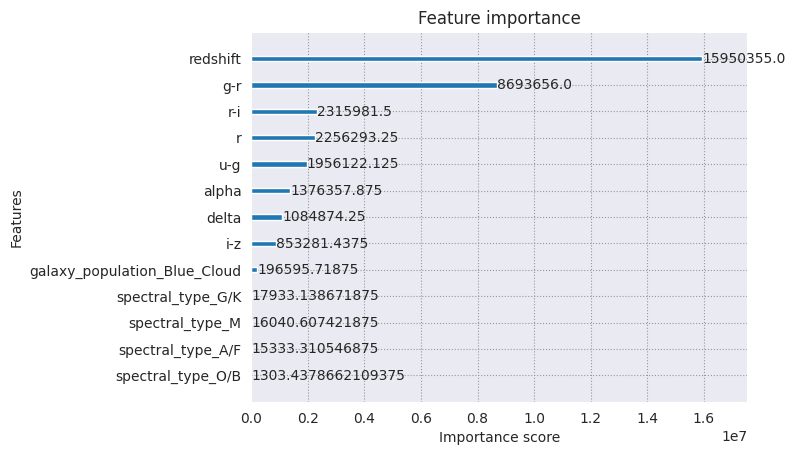

In [63]:
from xgboost import plot_importance

# plot feature importance
plot_importance(bst,  importance_type='total_gain')
plt.show()

### **Submitting**


In [64]:
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')
test

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...
247430,824777,248.013903,49.533434,21.563545,21.716868,21.670791,21.265478,21.558618,1.214520,A/F,Blue_Cloud
247431,824778,226.823885,52.635936,21.434441,21.075412,20.778300,20.962333,21.010822,1.004950,A/F,Blue_Cloud
247432,824779,232.879335,44.948125,23.294670,22.336583,20.121142,19.405430,18.744581,0.269394,M,Red_Sequence
247433,824780,351.396802,2.451824,20.882944,20.902010,20.222812,20.551737,20.278339,1.199392,G/K,Blue_Cloud


In [66]:
test_id = test.id 
test['u-g'] = test['u'] - test['g']
test['g-r'] = test['g'] - test['r']
test['r-i'] = test['r'] - test['i']
test['i-z'] = test['i'] - test['z']
X = test.drop(columns = ['id', 'u', 'g', 'i', 'z'])
X = pd.get_dummies(X, columns=cat_col)

In [67]:
preds = bst.predict(X)


In [68]:
preds = LE.inverse_transform(preds)
preds

array(['GALAXY', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'QSO', 'GALAXY'],
      shape=(247435,), dtype=object)

In [70]:
submission = pd.DataFrame({'id': test_id, target: preds})
filename = f'submission.csv'
submission.to_csv(filename, index=False)
